<a href="https://colab.research.google.com/github/rb4050/DEEP_LEARING_CLG/blob/main/EXP__THREE__3__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.3602 - loss: 1.8443 - val_accuracy: 0.4369 - val_loss: 1.6345
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3957 - loss: 1.7090 - val_accuracy: 0.4369 - val_loss: 1.6396
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.3952 - loss: 1.7156 - val_accuracy: 0.4369 - val_loss: 1.6196
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.4002 - loss: 1.7029 - val_accuracy: 0.4369 - val_loss: 1.6381
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.3881 - loss: 1.7208 - val_accuracy: 0.4369 - val_loss: 1.6622
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3758 - loss: 1.7434 - val_accuracy: 0.4369 - val_loss: 1.6216
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.3938 - loss: 1.7196 - val_accuracy: 0.4369 - val_loss: 1.6254
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.3819 - loss: 1.7439 - val_accuracy: 0.4369 - val_loss: 1

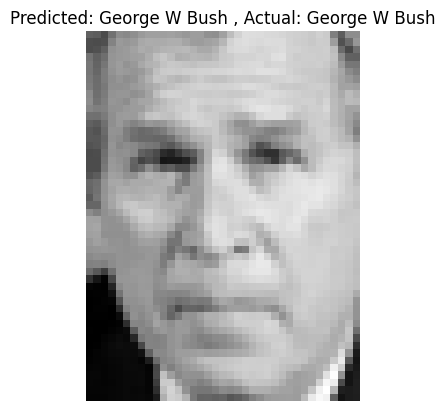

In [ ]:
# ==========================================
# FACE RECOGNITION USING CNN (LFW dataset)
# ==========================================

# Step 1: Import libraries
import numpy as np
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


# Step 2: Load dataset (only persons with 70+ images)
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

X = lfw.images           # image data
y = lfw.target           # labels (names)
target_names = lfw.target_names

# Normalize pixel values (0–255 → 0–1)
X = X / 255.0

# CNN expects (height, width, channels)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)


# Step 3: Prepare labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)
y = to_categorical(y)      # one-hot encoding

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Step 4: Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(X.shape[1], X.shape[2], 1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(100, activation='relu'),
    Dense(y.shape[1], activation='softmax')   # output layer = number of persons
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


# Step 5: Train CNN
model.fit(x_train, y_train, epochs=10, validation_split=0.1)


# Step 6: Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("✅ Test Accuracy:", acc)


# Step 7: Predict on sample image
pred = model.predict(x_test[:1])
class_index = np.argmax(pred)

plt.imshow(x_test[0].reshape(X.shape[1], X.shape[2]), cmap='gray')

actual_class = np.argmax(y_test[0])  # Convert one-hot encoded label to index

plt.title(f"Predicted: {target_names[class_index]} , Actual: {target_names[actual_class]}")
plt.axis('off')
plt.show()
